# Klassificering av ansiktsuttryck med deep learning

In [1]:
# Grundläggande bibliotek
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Train/validation-split och utvärdering
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping

tf.keras.utils.set_random_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## 1 Förstå datan

In [2]:
# Titta på datan

import os

print("Antal klasser i train:", len(os.listdir("data/train")))
for class_name in sorted(os.listdir("data/train")):
    count = len(os.listdir(f"data/train/{class_name}"))
    print(f"{class_name}: {count} bilder")

print(f"\nAntal klasser i test:", len(os.listdir("data/test")))
for class_name in sorted(os.listdir("data/test")):
    count = len(os.listdir(f"data/test/{class_name}"))
    print(f"{class_name}: {count} bilder")

Antal klasser i train: 7
angry: 3995 bilder
disgust: 436 bilder
fear: 4097 bilder
happy: 7215 bilder
neutral: 4965 bilder
sad: 4830 bilder
surprise: 3171 bilder

Antal klasser i test: 7
angry: 958 bilder
disgust: 111 bilder
fear: 1024 bilder
happy: 1774 bilder
neutral: 1233 bilder
sad: 1247 bilder
surprise: 831 bilder


### Kommentar:  
Klassen disgust sticker ut med färre bilder 436, runt 10 procent av övriga. Störst är klassen happy med 7215 bilder.

## 2 Förbered datan

In [3]:
# Packa upp zip-filen

import zipfile

with zipfile.ZipFile("data/FER-2013.zip", "r") as zip_ref:
    zip_ref.extractall("data/")

### Läser in data  

Datan läses in med ImageDataGenerator och normaliseras genom att pixelvärdena skalas från 0-255 till 0-1. Med flow_from_directory skalas bilderna till 48x48 pixlar och en kanal för gråskala. Labels sätts till heltal (sparse). För att underlätta vidare arbete så konverteras datan till numpy arrays.

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_dir = "data/train"
test_dir = "data/test"

datagen = ImageDataGenerator(rescale=1./255)

train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(48, 48),
    color_mode="grayscale",
    class_mode="sparse",
    batch_size=32,
    shuffle=False
)

test_generator = datagen.flow_from_directory(
    test_dir,
    target_size=(48, 48),
    color_mode="grayscale",
    class_mode="sparse",
    batch_size=32,
    shuffle=False
)

# Konvertera till numpy-arrays
X_train_full = np.concatenate([train_generator[i][0] for i in range(len(train_generator))], axis=0)
y_train_full = np.concatenate([train_generator[i][1] for i in range(len(train_generator))], axis=0).astype(int)

X_test = np.concatenate([test_generator[i][0] for i in range(len(test_generator))], axis=0)
y_test = np.concatenate([test_generator[i][1] for i in range(len(test_generator))], axis=0).astype(int)

class_names = list(train_generator.class_indices.keys())

print("X_train_full:", X_train_full.shape)
print("y_train_full:", y_train_full.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)
print(f"\nLabels på klasserna:")
for i, name in enumerate(class_names):
    print(i, name)

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.
X_train_full: (28709, 48, 48, 1)
y_train_full: (28709,)
X_test: (7178, 48, 48, 1)
y_test: (7178,)

Labels på klasserna:
0 angry
1 disgust
2 fear
3 happy
4 neutral
5 sad
6 surprise


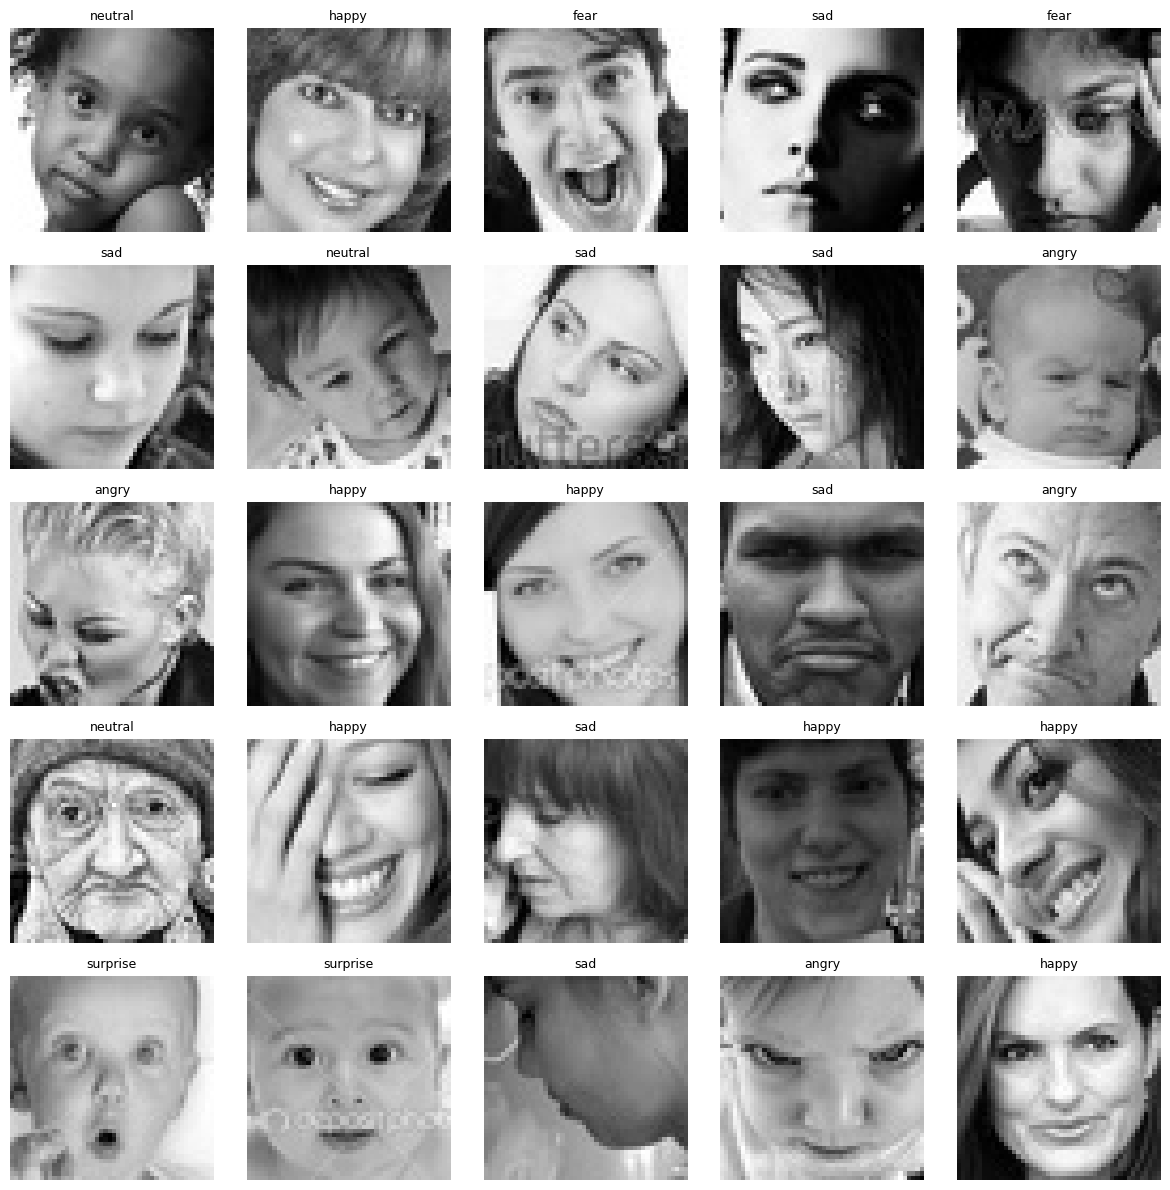

In [5]:
def  plot_image_grid(X, y, class_names, n_images=25, random_state=42):

    """
    Visar ett rutnät med slumpmässigt utvalda bilder och deras klassnamn.
    
    Parametrar:
        X: bilddata som numpy-array
        y: labels som numpy-array
        class_names: lista med klassnamn
        n_images: antal bilder att visa (standard 25)
        random_state: slumpfrö för reproducerbarhet
    """

    rng = np.random.default_rng(random_state)
    indices = rng.choice(len(X), size=n_images, replace=False)

    grid_size = int(np.ceil(np.sqrt(n_images)))

    plt.figure(figsize=(12, 12))
    
    for plot_index, image_index in enumerate(indices):
        plt.subplot(grid_size, grid_size, plot_index + 1)
        plt.imshow(X[image_index].squeeze(), cmap="gray")
        plt.title(class_names[y[image_index]], fontsize=9)
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()


plot_image_grid(
    X_train_full,
    y_train_full,
    class_names,
    n_images=25
)

### Kommentar

Då klassen "disgust" innehåll betydligt färre bilder än övriga klasser så kommer klassen tas bort just nu för att få en mer robust modell. Om mer data 
samlas in i framtiden kan modellen tränas om med klassen inkluderad.  

Träningssetet innehåller 28709 bilder vilket kan ta lång tid att träna på. Experimneten kommer därför utföras på ett balanserat subset där alla klasser får lika stor storlek så att modellen blir lika bra på att känna igen alla klasser. När en optimal modell hittats kan träning ske på hela träningsdatan.

### Ta bort klassen disgust

In [6]:
# Ta bort disgust (klass 1)

mask = y_train_full != 1
X_filtered = X_train_full[mask]
y_filtered = y_train_full[mask]

# Mappa om labels till 0-5
unique_labels = np.unique(y_filtered)
label_map = {old: new for new, old in enumerate(unique_labels)}
y_filtered = np.array([label_map[y] for y in y_filtered])

class_names_filtered = [name for name in class_names if name != "disgust"]

### Skapa subset

In [7]:
def create_balanced_subset(X, y, samples_per_class=500, random_state=42):

    """
    Skapar ett balanserat subset av bilder och plotta dem i ett grid.

    Parametrar:
    X: bilddata som numpy-array
    y: labels som numpy-array
    samples_per_class: antal bilder per klass (standard 500)
    random_state: slumpfrö för reproducerbarhet
    
    Returnerar:
        X och y med samples_per_class bilder per klass, slumpmässigt blandade
    """
    
    rng = np.random.default_rng(random_state)
    selected_indices = []

    for class_id in np.unique(y):
        class_indices = np.where(y == class_id)[0]

        if len(class_indices) < samples_per_class:
            raise ValueError(
                f"Klassen {class_id} har bara {len(class_indices)} exempel, "
                f"men samples_per_class={samples_per_class}"
            )
        
        chosen_indices = rng.choice(class_indices, size=samples_per_class, replace=False)
        selected_indices.extend(chosen_indices)
    
    selected_indices = np.array(selected_indices)
    rng.shuffle(selected_indices)
    return X[selected_indices], y[selected_indices]


X_subset_raw, y_subset = create_balanced_subset(
    X_filtered,
    y_filtered,
    samples_per_class=500,
    random_state=42
)

print("X_subset_raw:", X_subset_raw.shape)
print("y_subset:", y_subset.shape)
print("\nLabels på klasserna efter borttagning av disgust och subset:")
unique, counts = np.unique(y_subset, return_counts=True)
for label, count in zip(unique, counts):
    print(f"{label} {class_names_filtered[label]}: {count} bilder")

X_subset_raw: (3000, 48, 48, 1)
y_subset: (3000,)

Labels på klasserna efter borttagning av disgust och subset:
0 angry: 500 bilder
1 fear: 500 bilder
2 happy: 500 bilder
3 neutral: 500 bilder
4 sad: 500 bilder
5 surprise: 500 bilder


### Skapa valideringsset

In [8]:
X_train, X_val, y_train, y_val = train_test_split(
    X_subset_raw,
    y_subset,
    test_size=0.20,
    random_state=42,
    stratify=y_subset
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

X_train: (2400, 48, 48, 1)
X_val: (600, 48, 48, 1)
y_train: (2400,)
y_val: (600,)


## 3 Bygg en modell

### Funktion för att bygga, compilera och träna modeller

In [9]:
def build_model(
        num_filters_1=32,
        num_filters_2=64,
        kernel_size=(3, 3),
        dense_units=128,
        learning_rate=0.001,
        dropout_rate=0.0,
        l2_strength=0.0
):
    """
    Bygger och kompilerar en Keras CNN-modell med angivna hyperparametrar.
    """

    kernels_regularizer = (
        regularizers.l2(l2_strength)
        if l2_strength > 0
        else None
    )

    model = keras.Sequential([
        layers.Input(shape=(48, 48, 1)),

        layers.Conv2D(num_filters_1, kernel_size=kernel_size, activation="relu",
                      padding="same", kernel_regularizer=kernels_regularizer),

        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Conv2D(num_filters_2, kernel_size=kernel_size, activation="relu",
                      padding="same", kernel_regularizer=kernels_regularizer),
                      
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Flatten(),
    ])

    model.add(layers.Dense(dense_units, activation="relu",
                           kernel_regularizer=kernels_regularizer))

    if dropout_rate > 0:
        model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(6, activation="softmax"))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

### Funktion för att skapa träningskurvor

In [10]:
def plot_history(history, title="Träningskurvor"):

    """
    Plottar tränings- och valideringsförlust samt accuracy över epoker.
    
    Parametrar:
        history: history-objekt returnerat från model.fit()
        title: rubrik för hela figuren (standard "Träningskurvor")
    """
        
    history_df = pd.DataFrame(history.history)

    epochs = range(1, len(history_df) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history_df["loss"], label="Traning loss")
    plt.plot(epochs, history_df["val_loss"], label="Validation loss")
    plt.xlabel("Epok")
    plt.ylabel("Loss")
    plt.title("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history_df["accuracy"], label="Traning accuracy")
    plt.plot(epochs, history_df["val_accuracy"], label="Validation accuracy")
    plt.xlabel("Epok")
    plt.ylabel("Accuracy")
    plt.title("Accuracy")
    plt.legend()

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

### Funktion för att köra experiment

In [11]:
def run_experiment(
        name,
        epochs=15,
        learning_rate=0.001,
        batch_size=64,
        num_filters_1=32,
        num_filters_2=64,
        kernel_size=(3, 3),
        dense_units=128,
        dropout_rate=0.0,
        l2_strength=0.0,
        callbacks=None,
        verbose=0
):
    model = build_model(
        num_filters_1=num_filters_1,
        num_filters_2=num_filters_2,
        kernel_size=kernel_size,
        dense_units=dense_units,
        learning_rate=learning_rate,
        dropout_rate=dropout_rate,
        l2_strength=l2_strength
    )

    print(f"\nExperiment: {name}")
    start_time = time.time()

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=verbose
    )

    training_time = time.time() - start_time

    train_acc  = history.history["accuracy"][-1]
    train_loss = history.history["loss"][-1]
    val_acc  = history.history["val_accuracy"][-1]
    val_loss = history.history["val_loss"][-1]


    print(f"Antal epoker:   {len(history.history['loss'])}")
    print(f"Train accuracy:      {train_acc:.4f}")
    print(f"Train loss:          {train_loss:.4f}")
    print(f"Validation accuracy: {val_acc:.4f}")
    print(f"Validation loss:     {val_loss:.4f}")
    print(f"Träningstid:    {training_time:.2f} sekunder")

    plot_history(history, title=name)

    return model, history, {
        "name": name,
        "train_accuracy": train_acc,
        "train_loss": train_loss,
        "val_accuracy": val_acc,
        "val_loss": val_loss,
        "epochs_trained": len(history.history["loss"]),
        "training_time": training_time
    }


Experiment: Basmodell
Antal epoker:   15
Train accuracy:      0.7950
Train loss:          0.5968
Validation accuracy: 0.3600
Validation loss:     2.1927
Träningstid:    21.74 sekunder


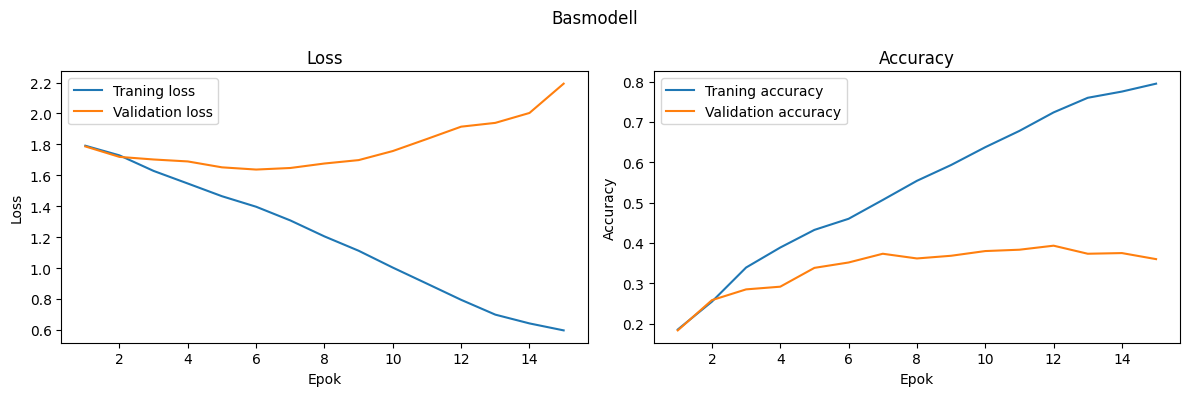

     name  train_accuracy  train_loss  val_accuracy  val_loss  epochs_trained  training_time
Basmodell           0.795    0.596786          0.36  2.192748              15      21.744755


In [12]:
# Basmodell

results_general = []

_, h_bas, r_bas = run_experiment("Basmodell")

results_general.append(r_bas)

print(pd.DataFrame(results_general).to_string(index=False))

### Kommentar

Basmodellen överanpassar nästan omgående och efter 15 epoker når accuracy på träningsdatan 0,80 men på valideringsdatan bara 0,36.  
Ett nästa steg är att prova olika dropout-nivåer där en del av neuronen inte används.


Experiment: Dropout 0.2
Antal epoker:   15
Train accuracy:      0.7283
Train loss:          0.7491
Validation accuracy: 0.4233
Validation loss:     1.8064
Träningstid:    20.21 sekunder


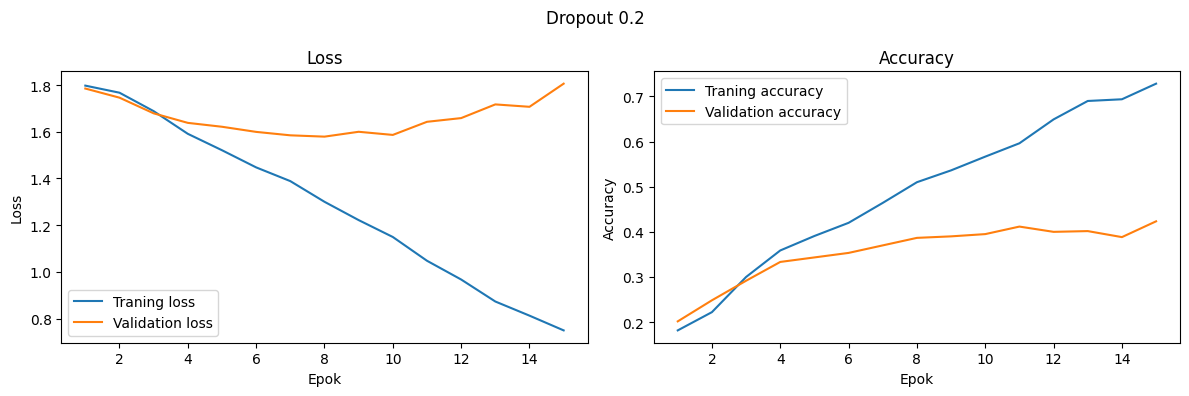


Experiment: Dropout 0.4
Antal epoker:   15
Train accuracy:      0.6883
Train loss:          0.8513
Validation accuracy: 0.3750
Validation loss:     1.7407
Träningstid:    21.47 sekunder


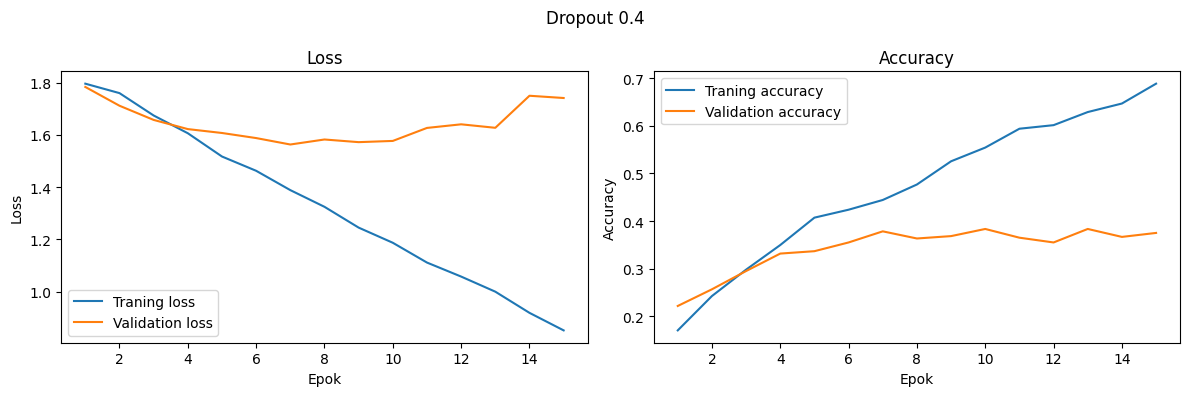


Experiment: Dropout 0.5
Antal epoker:   15
Train accuracy:      0.6612
Train loss:          0.9188
Validation accuracy: 0.3883
Validation loss:     1.6692
Träningstid:    22.36 sekunder


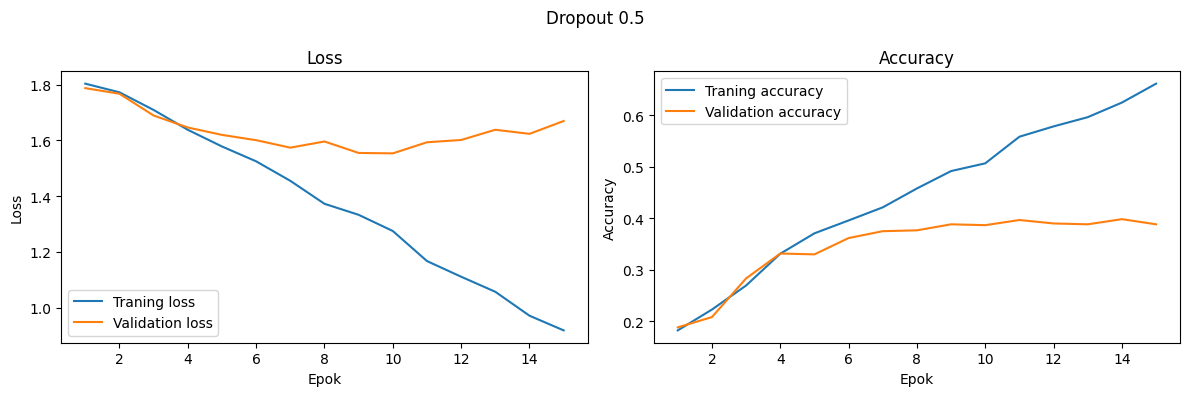

       name  train_accuracy  train_loss  val_accuracy  val_loss  epochs_trained  training_time
  Basmodell        0.795000    0.596786      0.360000  2.192748              15      21.744755
Dropout 0.2        0.728333    0.749116      0.423333  1.806363              15      20.207646
Dropout 0.4        0.688333    0.851295      0.375000  1.740726              15      21.468301
Dropout 0.5        0.661250    0.918845      0.388333  1.669178              15      22.363699


In [13]:
# Experiment med olika dropout

_, h_drop1, r_drop1 = run_experiment("Dropout 0.2", dropout_rate=0.2)
_, h_drop2, r_drop2 = run_experiment("Dropout 0.4", dropout_rate=0.4)
_, h_drop3, r_drop3 = run_experiment("Dropout 0.5", dropout_rate=0.5)

results_general.extend([r_drop1, r_drop2, r_drop3])
print(pd.DataFrame(results_general).to_string(index=False))

### Kommentar

Med dropout 0,2 fås den hittils bästa accuracy på valideringsdatan. Tillsammans med att accuracy på träningsdatan sjunker så ger detta det minsta gapet dem emellan. Även om dropout 0,2 inte har minst loss på valideringsdatan så väljs detta att gå vidare med då accuracy prioiteras.  

För att ytterligare minska överanpassning testas olika l2-styrkor som straffar modellen om den har för stora vikter.


Experiment: Dropout 0.2 + L2 0.01
Antal epoker:   15
Train accuracy:      0.3038
Train loss:          1.7248
Validation accuracy: 0.3100
Validation loss:     1.7410
Träningstid:    26.29 sekunder


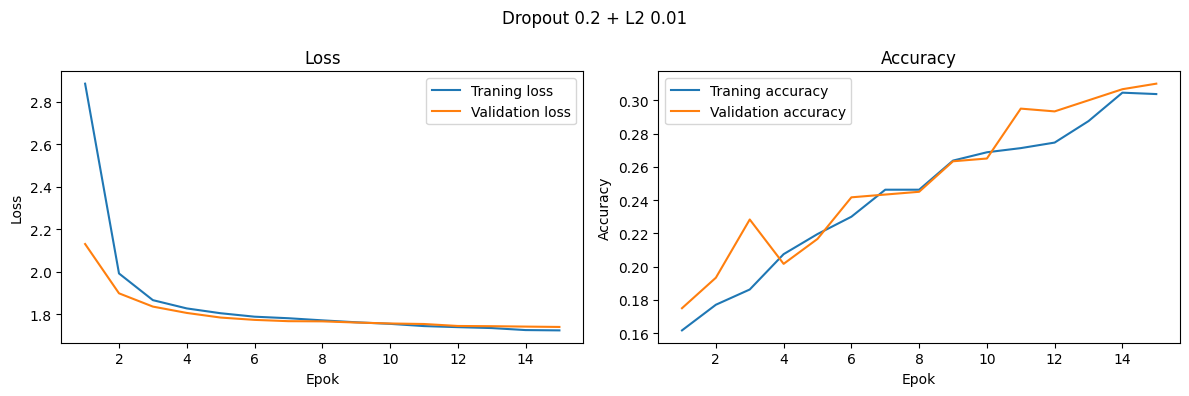


Experiment: Dropout 0.2 + L2 0.001
Antal epoker:   15
Train accuracy:      0.5958
Train loss:          1.2021
Validation accuracy: 0.3633
Validation loss:     1.7606
Träningstid:    28.90 sekunder


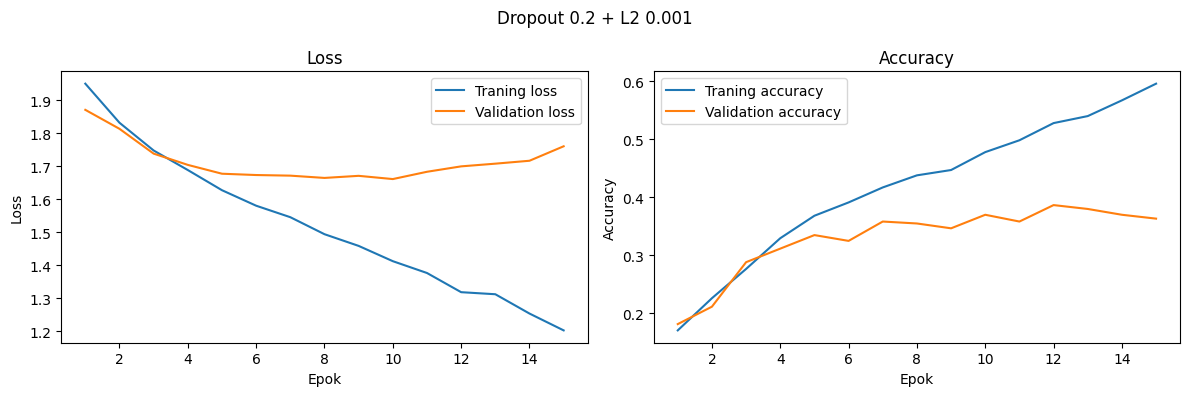


Experiment: Dropout 0.2 + L2 0.0001
Antal epoker:   15
Train accuracy:      0.6404
Train loss:          1.0229
Validation accuracy: 0.3550
Validation loss:     1.7601
Träningstid:    24.16 sekunder


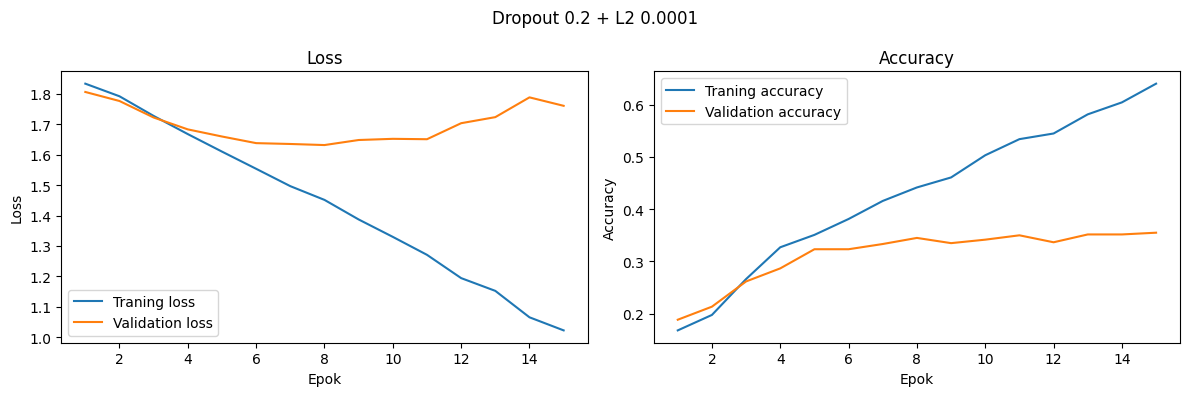

                   name  train_accuracy  train_loss  val_accuracy  val_loss  epochs_trained  training_time
              Basmodell        0.795000    0.596786      0.360000  2.192748              15      21.744755
            Dropout 0.2        0.728333    0.749116      0.423333  1.806363              15      20.207646
            Dropout 0.4        0.688333    0.851295      0.375000  1.740726              15      21.468301
            Dropout 0.5        0.661250    0.918845      0.388333  1.669178              15      22.363699
  Dropout 0.2 + L2 0.01        0.303750    1.724787      0.310000  1.740954              15      26.290152
 Dropout 0.2 + L2 0.001        0.595833    1.202088      0.363333  1.760634              15      28.896453
Dropout 0.2 + L2 0.0001        0.640417    1.022874      0.355000  1.760130              15      24.155406


In [14]:
# Experiment med olika L2-styrkor

_, h_l2_1, r_l2_1 = run_experiment("Dropout 0.2 + L2 0.01", dropout_rate=0.2, l2_strength=0.01)
_, h_l2_2, r_l2_2 = run_experiment("Dropout 0.2 + L2 0.001", dropout_rate=0.2, l2_strength=0.001)
_, h_l2_3, r_l2_3 = run_experiment("Dropout 0.2 + L2 0.0001", dropout_rate=0.2, l2_strength=0.0001)

results_general.extend([r_l2_1, r_l2_2, r_l2_3])
print(pd.DataFrame(results_general).to_string(index=False))

### Kommentar

L2-regularisering gav ingen förbättring utan modellen men dropout 0,2 är fortfarande bästa. Att testa early stopping bedöms inte meningsfullt då överanpassning fortfarande inom 6-8 epoker. Nästa experiment görs med olika learning rates


Experiment: Dropout 0.2 + LR 0.0001
Antal epoker:   15
Train accuracy:      0.4412
Train loss:          1.4490
Validation accuracy: 0.3633
Validation loss:     1.6140
Träningstid:    23.63 sekunder


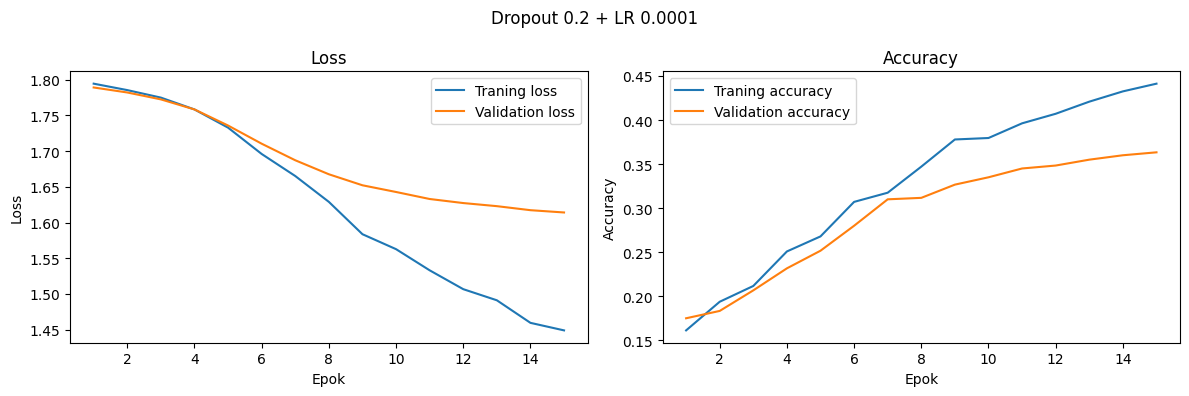


Experiment: Dropout 0.2 + LR 0.0005
Antal epoker:   15
Train accuracy:      0.5683
Train loss:          1.1761
Validation accuracy: 0.3850
Validation loss:     1.5796
Träningstid:    24.56 sekunder


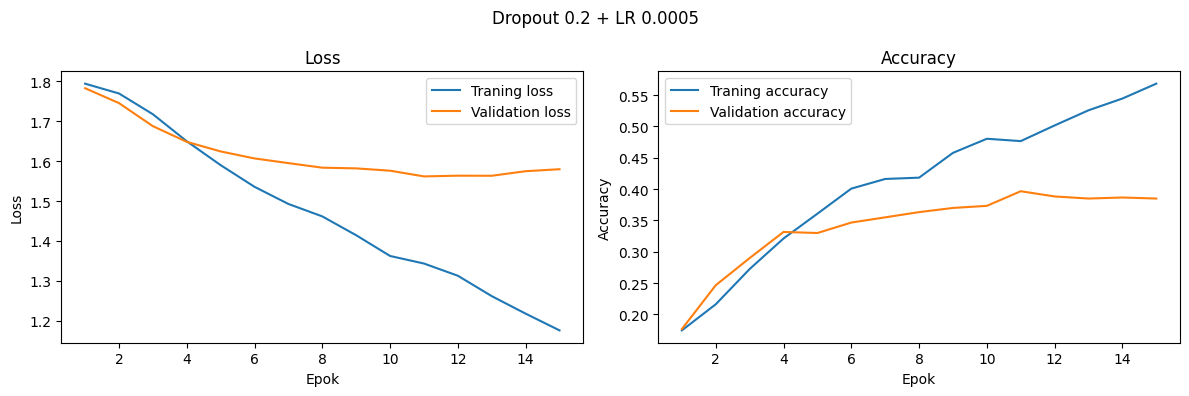


Experiment: Dropout 0.2 + LR 0.01
Antal epoker:   15
Train accuracy:      0.1567
Train loss:          1.7926
Validation accuracy: 0.1667
Validation loss:     1.7918
Träningstid:    23.10 sekunder


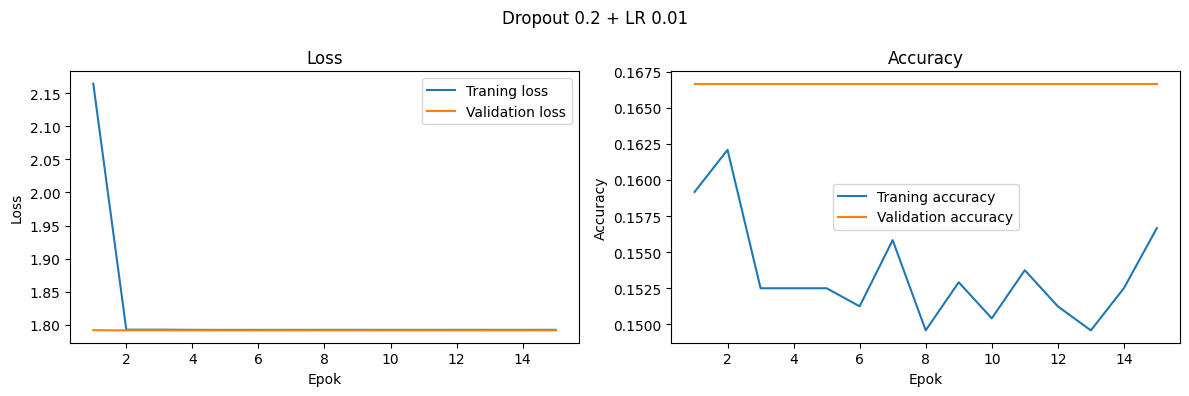

                   name  train_accuracy  train_loss  val_accuracy  val_loss  epochs_trained  training_time
              Basmodell        0.795000    0.596786      0.360000  2.192748              15      21.744755
            Dropout 0.2        0.728333    0.749116      0.423333  1.806363              15      20.207646
            Dropout 0.4        0.688333    0.851295      0.375000  1.740726              15      21.468301
            Dropout 0.5        0.661250    0.918845      0.388333  1.669178              15      22.363699
  Dropout 0.2 + L2 0.01        0.303750    1.724787      0.310000  1.740954              15      26.290152
 Dropout 0.2 + L2 0.001        0.595833    1.202088      0.363333  1.760634              15      28.896453
Dropout 0.2 + L2 0.0001        0.640417    1.022874      0.355000  1.760130              15      24.155406
Dropout 0.2 + LR 0.0001        0.441250    1.448974      0.363333  1.614049              15      23.626970
Dropout 0.2 + LR 0.0005        0.5683

In [15]:
# Experiment med olika learning rates

_, h_lr1, r_lr1 = run_experiment("Dropout 0.2 + LR 0.0001", dropout_rate=0.2, learning_rate=0.0001)
_, h_lr2, r_lr2 = run_experiment("Dropout 0.2 + LR 0.0005", dropout_rate=0.2, learning_rate=0.0005)
_, h_lr3, r_lr3 = run_experiment("Dropout 0.2 + LR 0.01", dropout_rate=0.2, learning_rate=0.01)

results_general.extend([r_lr1, r_lr2, r_lr3])
print(pd.DataFrame(results_general).to_string(index=False))

### Kommentar

De testade learning rates gav ingen förbättring utan learning rate 0,001 som användes som grund är tillsammans med droput 0,2 bäst hittils. I nästa experiment testas en större modell för att se om den kan lära sig de mer komplexa mönster som ansiktsuttryck är.


Experiment: Större modell + dropout 0.2
Antal epoker:   15
Train accuracy:      0.8492
Train loss:          0.4433
Validation accuracy: 0.3633
Validation loss:     2.3417
Träningstid:    65.41 sekunder


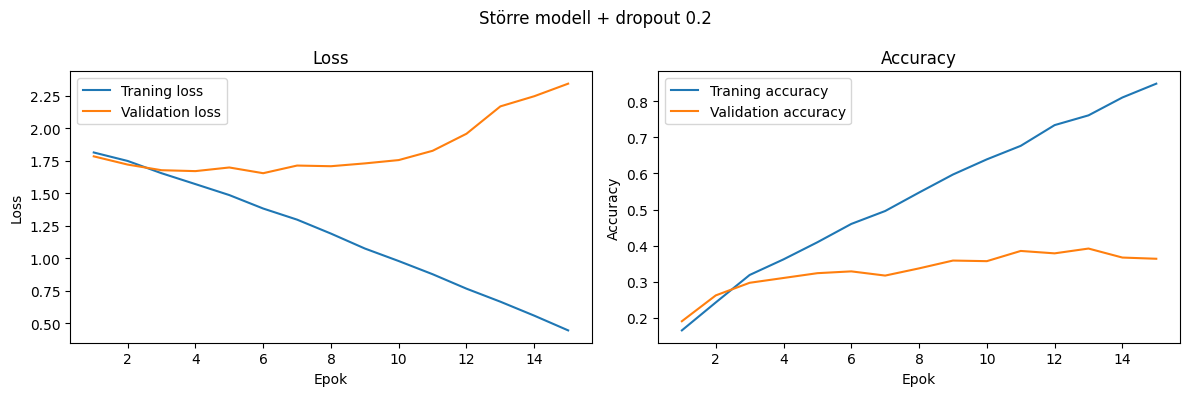

                       name  train_accuracy  train_loss  val_accuracy  val_loss  epochs_trained  training_time
                  Basmodell        0.795000    0.596786      0.360000  2.192748              15      21.744755
                Dropout 0.2        0.728333    0.749116      0.423333  1.806363              15      20.207646
                Dropout 0.4        0.688333    0.851295      0.375000  1.740726              15      21.468301
                Dropout 0.5        0.661250    0.918845      0.388333  1.669178              15      22.363699
      Dropout 0.2 + L2 0.01        0.303750    1.724787      0.310000  1.740954              15      26.290152
     Dropout 0.2 + L2 0.001        0.595833    1.202088      0.363333  1.760634              15      28.896453
    Dropout 0.2 + L2 0.0001        0.640417    1.022874      0.355000  1.760130              15      24.155406
    Dropout 0.2 + LR 0.0001        0.441250    1.448974      0.363333  1.614049              15      23.626970
 

In [16]:
# Experiment med större modell

_, h_big, r_big = run_experiment(
    "Större modell + dropout 0.2",
    num_filters_1=64,
    num_filters_2=128,
    dense_units=256,
    dropout_rate=0.2
)

results_general.append(r_big)
print(pd.DataFrame(results_general).to_string(index=False))

### Kommentar

En större modell överanpassar ännu mer med 0,85 i accuracy på träningsdatan och 0,36 på valideringsdatan.

### Träna modellen på hela träningsdatan

Modellen som väljs är basmodellen med dropout 0,2 tillagt.

In [17]:
# Skapa tränings- och valideringsuppsättningarm med alla bilder (utan disgust)

X_train_full, X_val_full, y_train_full, y_val_full = train_test_split(
    X_filtered,
    y_filtered,
    test_size=0.20,
    random_state=42,
    stratify=y_filtered
)

print("X_train:", X_train_full.shape)
print("X_val:", X_val_full.shape)
print("y_train:", y_train_full.shape)
print("y_val:", y_val_full.shape)

X_train: (22618, 48, 48, 1)
X_val: (5655, 48, 48, 1)
y_train: (22618,)
y_val: (5655,)



Experiment: Basmodell + dropout 0.2 på alla bilder
Antal epoker:   15
Train accuracy:      0.7326
Train loss:          0.6895
Validation accuracy: 0.4755
Validation loss:     1.8075
Träningstid:    205.55 sekunder


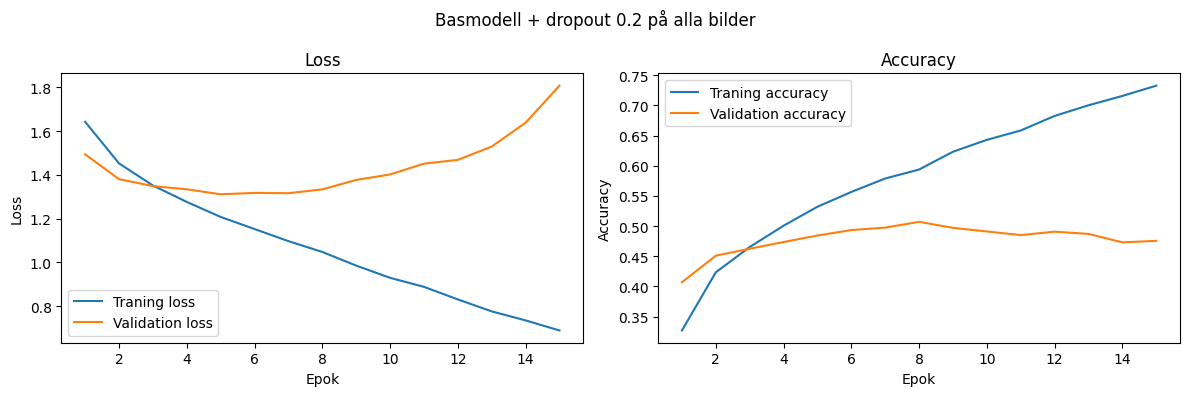

                                  name  train_accuracy  train_loss  val_accuracy  val_loss  epochs_trained  training_time
                             Basmodell        0.795000    0.596786      0.360000  2.192748              15      21.744755
                           Dropout 0.2        0.728333    0.749116      0.423333  1.806363              15      20.207646
                           Dropout 0.4        0.688333    0.851295      0.375000  1.740726              15      21.468301
                           Dropout 0.5        0.661250    0.918845      0.388333  1.669178              15      22.363699
                 Dropout 0.2 + L2 0.01        0.303750    1.724787      0.310000  1.740954              15      26.290152
                Dropout 0.2 + L2 0.001        0.595833    1.202088      0.363333  1.760634              15      28.896453
               Dropout 0.2 + L2 0.0001        0.640417    1.022874      0.355000  1.760130              15      24.155406
               Dropout 0

In [18]:
X_train = X_train_full
X_val = X_val_full
y_train = y_train_full
y_val = y_val_full

model_full, h_full, r_full = run_experiment(
    "Basmodell + dropout 0.2 på alla bilder",
    dropout_rate=0.2
)

results_general.append(r_full)
print(pd.DataFrame(results_general).to_string(index=False))

### Kommentar

Mer data gav en förbättring med bäst accuracy på valideringsdatan och ett mindre överanpassningsgap (73% train vs 47% val).

177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


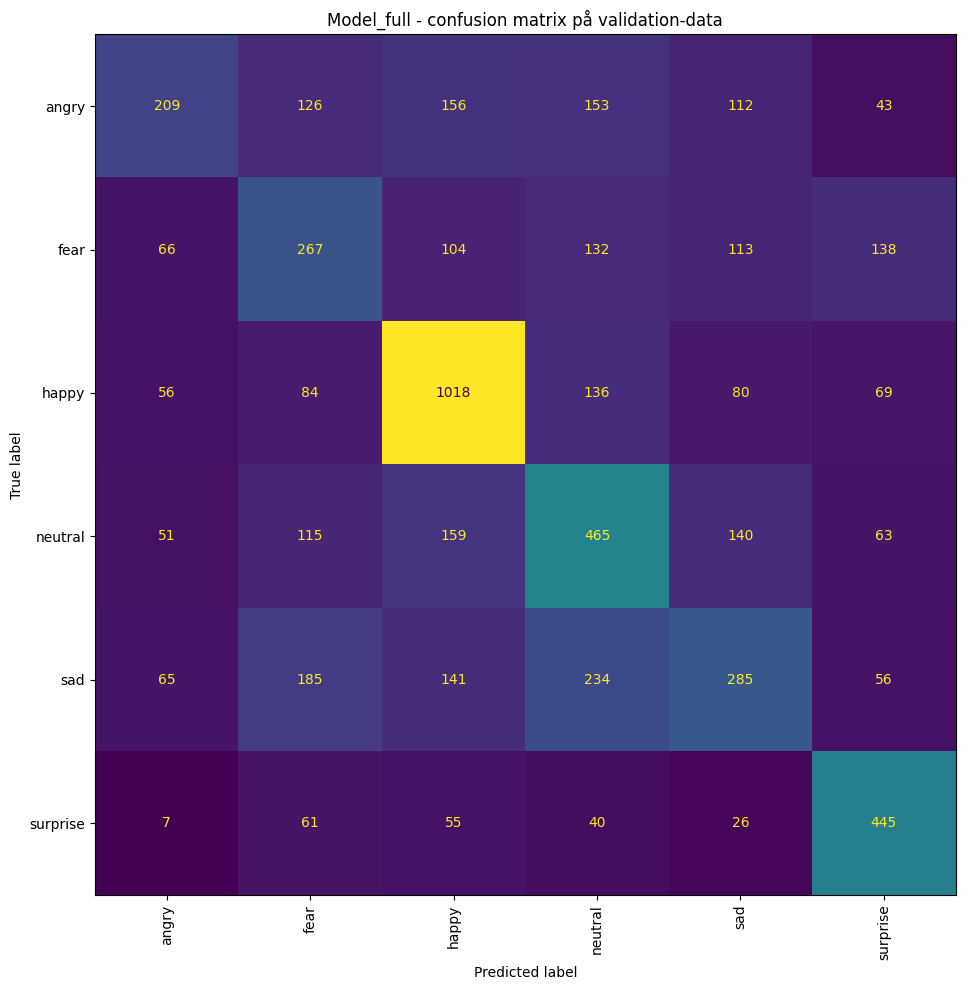

In [19]:
def plot_confusion_matrix(y_true, y_pred, class_names, title="Confusion matrix"):

    labels = np.arange(len(class_names))

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=labels
    )

    fig, ax = plt.subplots(figsize=(12, 10))

    display = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )

    display.plot(
        ax=ax,
        xticks_rotation=90,
        values_format="d",
        colorbar=False
    )

    plt.title(title)
    plt.tight_layout()
    plt.show()

    return cm

model_full_cm = plot_confusion_matrix(
    y_val,
    model_full.predict(X_val).argmax(axis=1),
    class_names_filtered,
    title="Model_full - confusion matrix på validation-data")

In [20]:
def calculate_per_class_accuracy(cm, class_names):

    support = cm.sum(axis=1)
    correct = np.diag(cm)

    accuracy = np.divide(
        correct,
        support,
        out=np.zeros_like(correct, dtype=float),
        where=support != 0
    )

    result = pd.DataFrame({
        "class_id": np.arange(len(class_names)),
        "class_name": class_names,
        "support": support,
        "correct": correct,
        "accuracy": accuracy
    })

    return result.sort_values("accuracy")


baseline_per_class = calculate_per_class_accuracy(
    model_full_cm,
    class_names_filtered
)

baseline_per_class

,class_id,class_name,support,correct,accuracy
0,0,angry,799,209,0.261577
4,4,sad,966,285,0.295031
1,1,fear,820,267,0.325610
3,3,neutral,993,465,0.468278
5,5,surprise,634,445,0.701893
2,2,happy,1443,1018,0.705475


In [21]:
def get_most_confused_pairs(cm, class_names, top_n=10):
    pairs = []

    for true_class in range(cm.shape[0]):
        for predicted_class in range(cm.shape[1]):
            if true_class == predicted_class:
                continue

            count = cm[true_class, predicted_class]

            if count > 0:
                pairs.append({
                    "true_class_id": true_class,
                    "true_class": class_names[true_class],
                    "predicted_class_id": predicted_class,
                    "predicted_class": class_names[predicted_class],
                    "count": count
                })

    pairs_df = pd.DataFrame(pairs)

    if pairs_df.empty:
        return pairs_df

    return pairs_df.sort_values("count", ascending=False).head(top_n)

baseline_confusions = get_most_confused_pairs(
    model_full_cm,
    class_names_filtered
)


In [22]:
def predict_classes(model, X):
    y_proba = model.predict(X, verbose=0)
    y_pred = np.argmax(y_proba, axis=1)
    return y_pred, y_proba
model_full_val_pred, model_full_val_proba = predict_classes(model_full, X_val)

Antal felklassificerade exempel: 2966


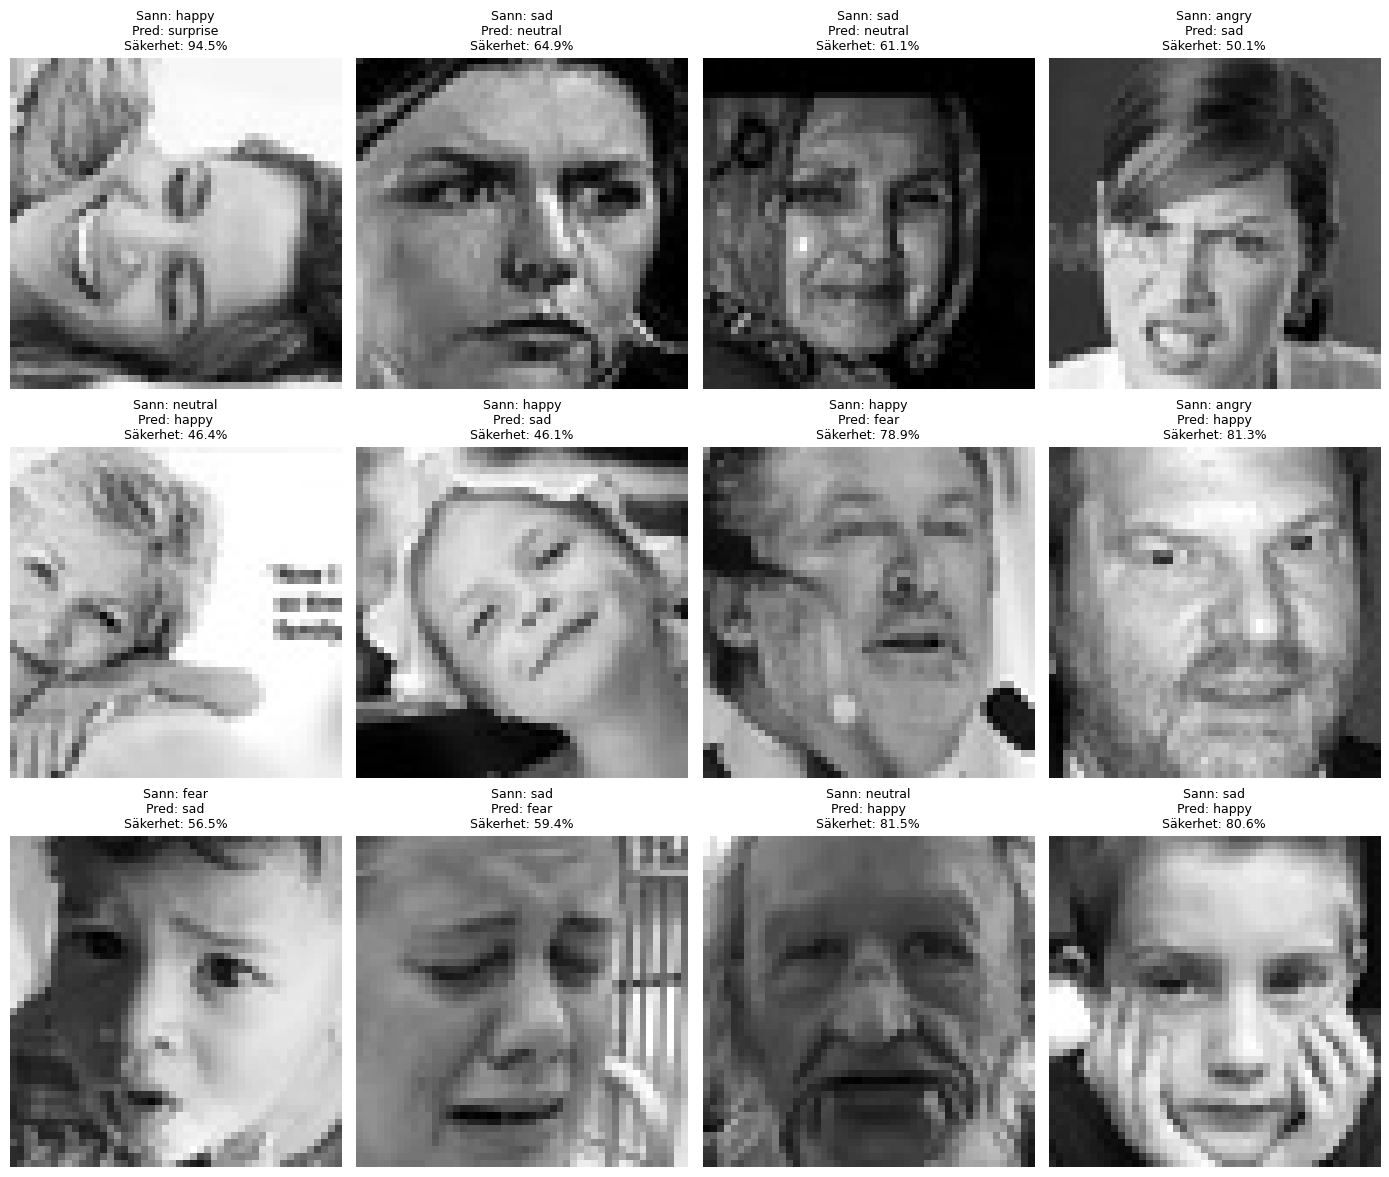

In [ ]:
def plot_misclassified_examples(
    X,
    y_true,
    y_pred,
    y_proba,
    class_names_filtered,
    n_images=12,
    random_state=42
):
    """
    Visar felklassificerade bilder.

    X:
        Bilddata, normaliserad eller i 0-1-format.

    y_true:
        Sanna labels.

    y_pred:
        Predikterade labels.

    y_proba:
        Sannolikheter från modellen.

    class_names_filtered:
        Lista med filtrerade klassnamn utan disgust.

    n_images:
        Antal felklassificerade bilder att visa.

    random_state:
        Seed för reproducerbart urval.
    """

    error_indices = np.where(y_true != y_pred)[0]

    print(f"Antal felklassificerade exempel: {len(error_indices)}")

    if len(error_indices) == 0:
        print("Inga felklassificerade exempel att visa.")
        return

    rng = np.random.default_rng(random_state)

    chosen_indices = rng.choice(
        error_indices,
        size=min(n_images, len(error_indices)),
        replace=False
    )

    cols = 4
    rows = int(np.ceil(len(chosen_indices) / cols))

    plt.figure(figsize=(14, 4 * rows))

    for plot_index, data_index in enumerate(chosen_indices):
        true_label = y_true[data_index]
        pred_label = y_pred[data_index]
        confidence = y_proba[data_index, pred_label] * 100

        plt.subplot(rows, cols, plot_index + 1)
        plt.imshow(X[data_index].squeeze(), cmap="gray")
        plt.title(
            f"Sann: {class_names_filtered[true_label]}\n"
            f"Pred: {class_names_filtered[pred_label]}\n"
            f"Säkerhet: {confidence:.1f}%",
            fontsize=9
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()

plot_misclassified_examples(
    X_val,
    y_val,
    model_full_val_pred,
    model_full_val_proba,
    class_names_filtered,
    n_images=12,
    random_state=42
)